# 🏥 ADR Detection System - Complete Implementation
## Prescription-to-Patient Automated Audit & ADR Detection

**Pipeline:**
1. Data Preprocessing
2. NER Model Training (Drug + Symptom Extraction)
3. ML Classification (ADR Detection)
4. Database Validation (SIDER)


## Installation & Imports

In [ ]:
!pip install spacy scikit-learn pandas numpy matplotlib seaborn wordcloud plotly rapidfuzz -q
!python -m spacy download en_core_web_sm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 17.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 56.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
import re, random, warnings, sqlite3, os
warnings.filterwarnings('ignore')

import spacy
from spacy.training.example import Example
from spacy.util import minibatch, compounding

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report,
                              confusion_matrix, roc_curve, auc)
from sklearn.pipeline import Pipeline
import joblib

print("✅ All libraries loaded")

✅ All libraries loaded


## Data Loading & Preprocessing

In [ ]:
df = pd.read_csv('/content/drugLibTrain_raw.csv')

In [ ]:
df.head()

,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above


In [ ]:
# Drop the unnamed index column
df = df.drop(columns=['Unnamed: 0'])

print("✅ Dataset Loaded")
print(f"   Shape       : {df.shape}")
print(f"   Columns     : {df.columns.tolist()}")
df.head(3)

✅ Dataset Loaded
   Shape       : (3107, 8)
   Columns     : ['urlDrugName', 'rating', 'effectiveness', 'sideEffects', 'condition', 'benefitsReview', 'sideEffectsReview', 'commentsReview']


,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...


In [ ]:
# ============================================================
# CELL 3: Raw EDA — Structure & Missing Values
# ============================================================
print("=" * 55)
print("  DATASET OVERVIEW — drugLibTrain_raw.csv")
print("=" * 55)
print(f"  Total Records      : {df.shape[0]:,}")
print(f"  Total Columns      : {df.shape[1]}")
print(f"  Unique Drugs       : {df['urlDrugName'].nunique()}")
print(f"  Unique Conditions  : {df['condition'].nunique()}")

print("\n--- Missing Values ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

print("\n--- sideEffects Distribution (Your ADR Signal) ---")
print(df['sideEffects'].value_counts())

print("\n--- effectiveness Distribution ---")
print(df['effectiveness'].value_counts())

print("\n--- Rating Distribution ---")
print(df['rating'].value_counts().sort_index())

  DATASET OVERVIEW — drugLibTrain_raw.csv
  Total Records      : 3,107
  Total Columns      : 8
  Unique Drugs       : 502
  Unique Conditions  : 1426

--- Missing Values ---
                   Missing Count  Missing %
condition                      1       0.03
benefitsReview                18       0.58
sideEffectsReview             75       2.41
commentsReview                12       0.39

--- sideEffects Distribution (Your ADR Signal) ---
sideEffects
Mild Side Effects                1019
No Side Effects                   930
Moderate Side Effects             614
Severe Side Effects               369
Extremely Severe Side Effects     175
Name: count, dtype: int64

--- effectiveness Distribution ---
effectiveness
Highly Effective          1330
Considerably Effective     928
Moderately Effective       415
Ineffective                247
Marginally Effective       187
Name: count, dtype: int64

--- Rating Distribution ---
rating
1     305
2     103
3     146
4     107
5     159
6     15

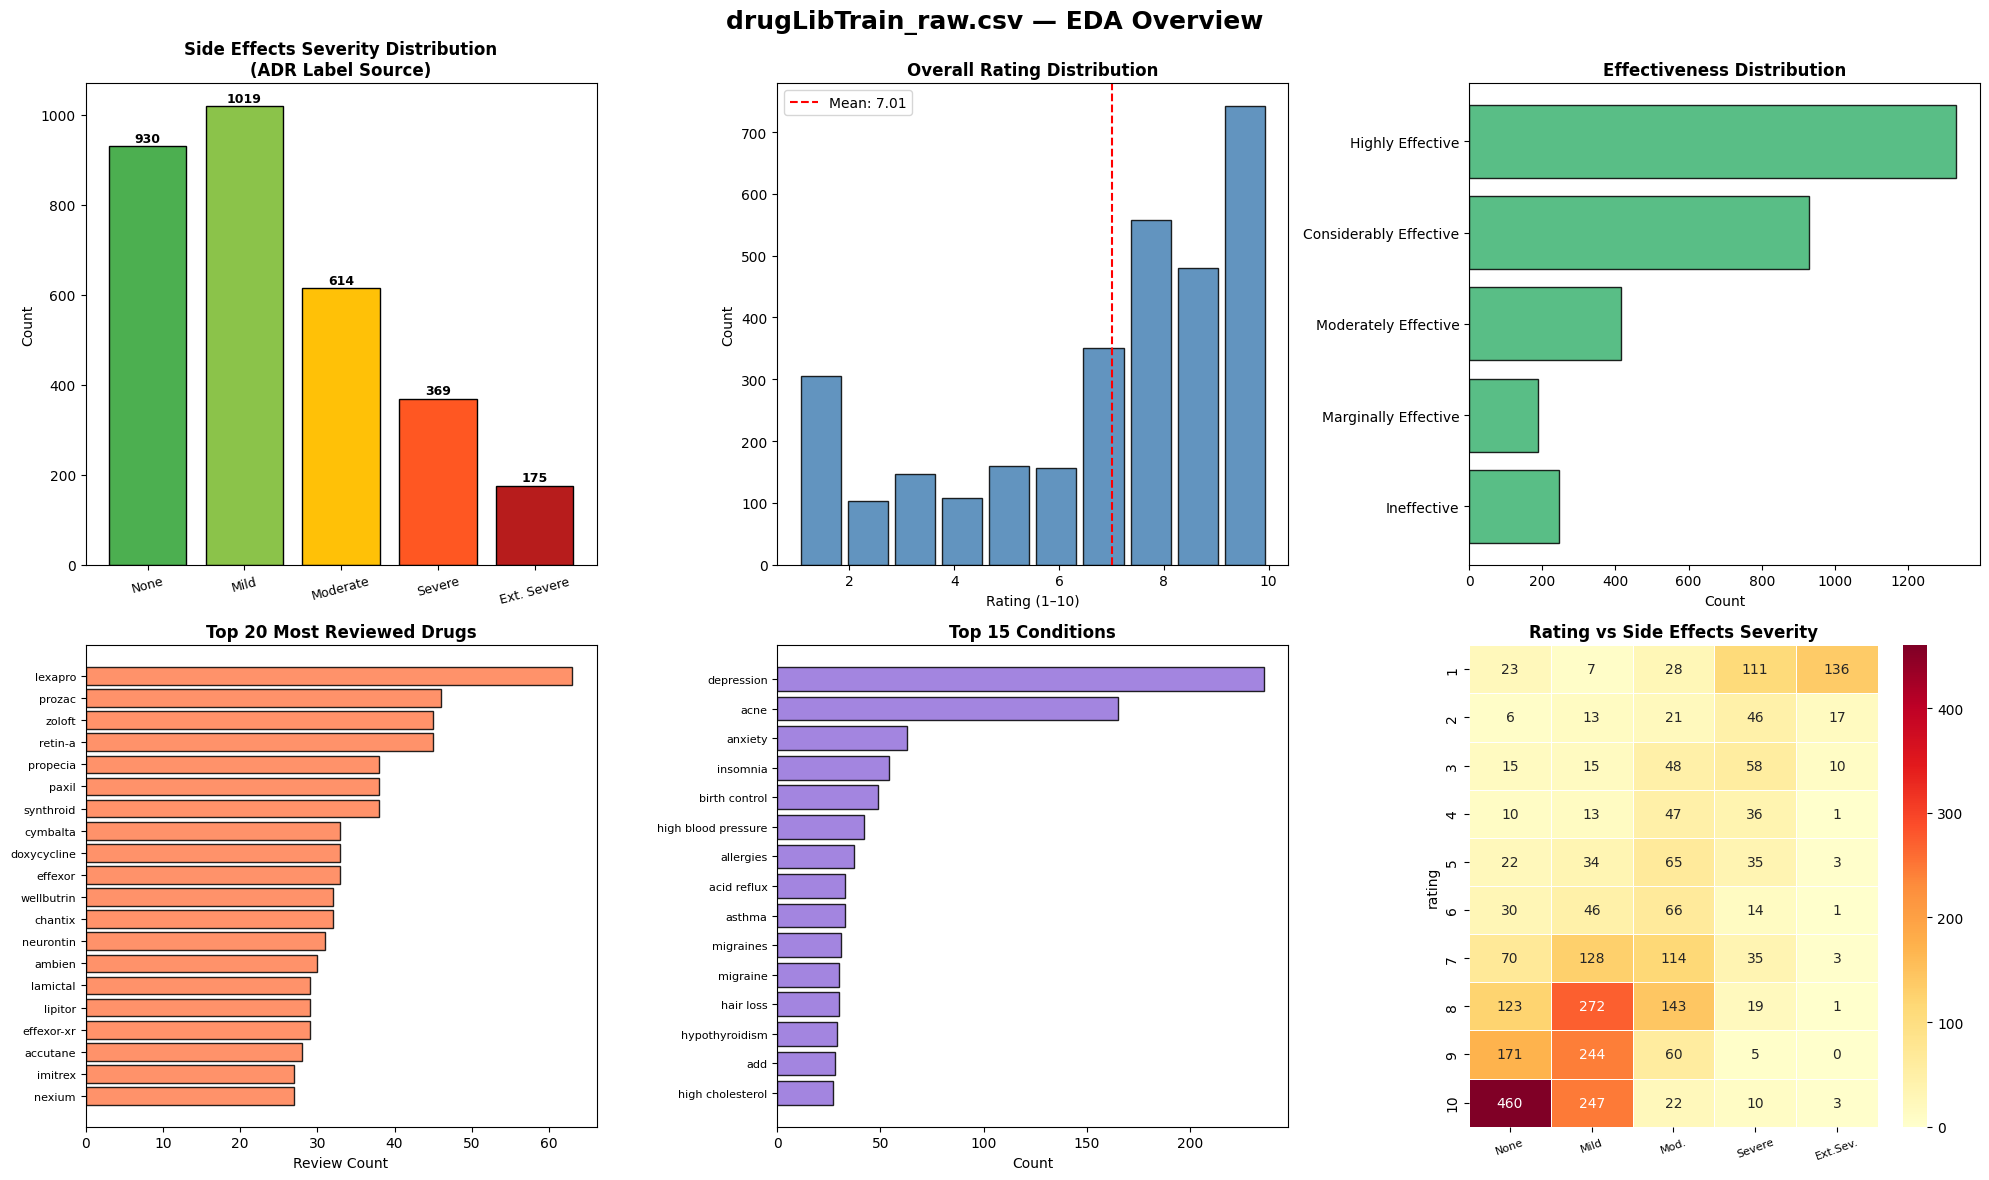

✅ EDA Plot Saved


In [ ]:
# ============================================================
# CELL 4: EDA Visualizations
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('drugLibTrain_raw.csv — EDA Overview', fontsize=18, fontweight='bold')

# --- 1: Side Effects Distribution (your actual ADR label source) ---
se_order = ['No Side Effects', 'Mild Side Effects', 'Moderate Side Effects',
            'Severe Side Effects', 'Extremely Severe Side Effects']
se_colors = ['#4CAF50', '#8BC34A', '#FFC107', '#FF5722', '#B71C1C']
se_counts = df['sideEffects'].value_counts().reindex(se_order)
bars = axes[0, 0].bar(range(len(se_order)), se_counts.values, color=se_colors, edgecolor='black')
axes[0, 0].set_xticks(range(len(se_order)))
axes[0, 0].set_xticklabels(['None', 'Mild', 'Moderate', 'Severe', 'Ext. Severe'],
                             fontsize=9, rotation=15)
axes[0, 0].set_title('Side Effects Severity Distribution\n(ADR Label Source)', fontweight='bold')
axes[0, 0].set_ylabel('Count')
for bar, count in zip(bars, se_counts.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                    str(count), ha='center', fontsize=9, fontweight='bold')

# --- 2: Rating Distribution ---
axes[0, 1].hist(df['rating'], bins=10, color='steelblue', edgecolor='black',
                alpha=0.85, rwidth=0.85)
axes[0, 1].axvline(df['rating'].mean(), color='red', linestyle='--',
                   label=f"Mean: {df['rating'].mean():.2f}")
axes[0, 1].set_title('Overall Rating Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Rating (1–10)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend()

# --- 3: Effectiveness Distribution ---
eff_order = ['Highly Effective', 'Considerably Effective', 'Moderately Effective',
             'Marginally Effective', 'Ineffective']
eff_counts = df['effectiveness'].value_counts().reindex(eff_order).fillna(0)
axes[0, 2].barh(eff_order[::-1], eff_counts.values[::-1],
                color='mediumseagreen', edgecolor='black', alpha=0.85)
axes[0, 2].set_title('Effectiveness Distribution', fontweight='bold')
axes[0, 2].set_xlabel('Count')

# --- 4: Top 20 Drugs ---
top_drugs = df['urlDrugName'].value_counts().head(20)
axes[1, 0].barh(top_drugs.index[::-1], top_drugs.values[::-1],
                color='coral', edgecolor='black', alpha=0.85)
axes[1, 0].set_title('Top 20 Most Reviewed Drugs', fontweight='bold')
axes[1, 0].set_xlabel('Review Count')
axes[1, 0].tick_params(axis='y', labelsize=8)

# --- 5: Top 15 Conditions ---
top_cond = df['condition'].value_counts().head(15)
axes[1, 1].barh(top_cond.index[::-1], top_cond.values[::-1],
                color='mediumpurple', edgecolor='black', alpha=0.85)
axes[1, 1].set_title('Top 15 Conditions', fontweight='bold')
axes[1, 1].set_xlabel('Count')
axes[1, 1].tick_params(axis='y', labelsize=8)

# --- 6: Rating vs Side Effects Heatmap ---
cross = pd.crosstab(df['rating'], df['sideEffects'])[se_order]
sns.heatmap(cross, ax=axes[1, 2], cmap='YlOrRd', annot=True, fmt='d',
            cbar=True, linewidths=0.5)
axes[1, 2].set_title('Rating vs Side Effects Severity', fontweight='bold')
axes[1, 2].set_xlabel('')
axes[1, 2].set_xticklabels(['None', 'Mild', 'Mod.', 'Severe', 'Ext.Sev.'],
                             rotation=20, fontsize=8)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA Plot Saved")

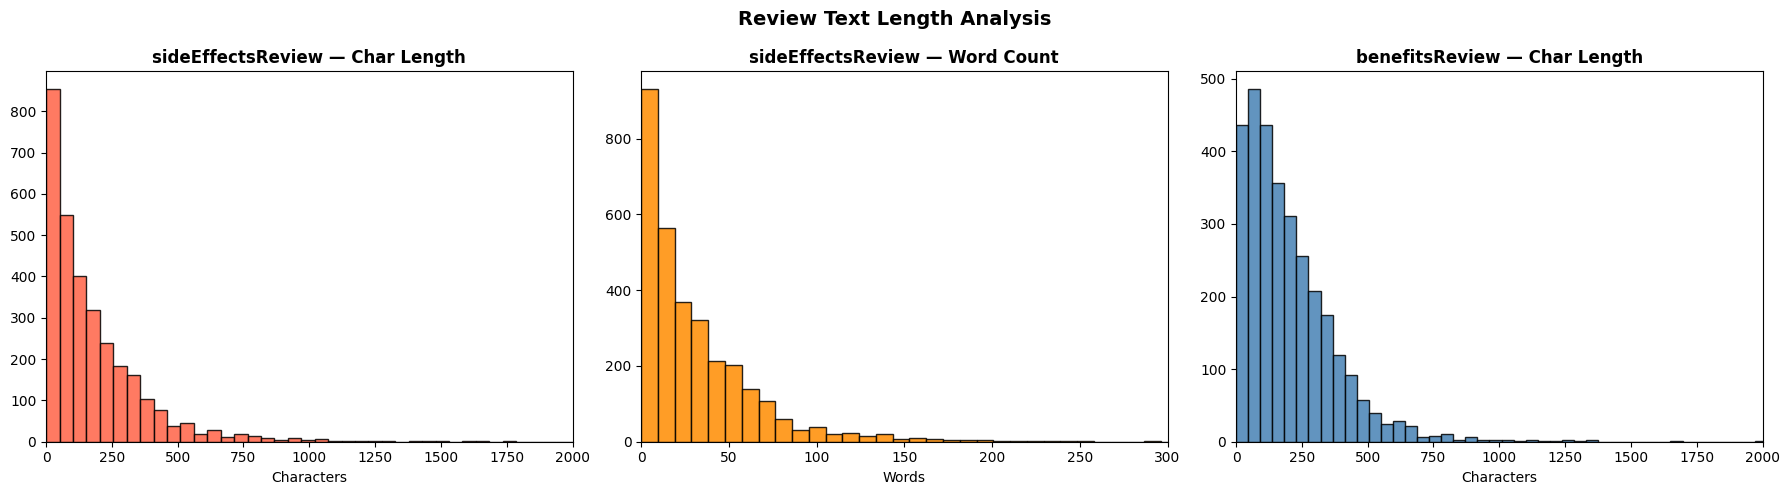

In [ ]:
# ============================================================
# CELL 5: Text Length Analysis — sideEffectsReview
# ============================================================
df['se_review_len']   = df['sideEffectsReview'].fillna('').apply(len)
df['se_word_count']   = df['sideEffectsReview'].fillna('').apply(lambda x: len(x.split()))
df['ben_review_len']  = df['benefitsReview'].fillna('').apply(len)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Review Text Length Analysis', fontsize=14, fontweight='bold')

axes[0].hist(df['se_review_len'], bins=50, color='tomato', edgecolor='black', alpha=0.85)
axes[0].set_title('sideEffectsReview — Char Length', fontweight='bold')
axes[0].set_xlabel('Characters')
axes[0].set_xlim(0, 2000)

axes[1].hist(df['se_word_count'], bins=50, color='darkorange', edgecolor='black', alpha=0.85)
axes[1].set_title('sideEffectsReview — Word Count', fontweight='bold')
axes[1].set_xlabel('Words')
axes[1].set_xlim(0, 300)

axes[2].hist(df['ben_review_len'], bins=50, color='steelblue', edgecolor='black', alpha=0.85)
axes[2].set_title('benefitsReview — Char Length', fontweight='bold')
axes[2].set_xlabel('Characters')
axes[2].set_xlim(0, 2000)

plt.tight_layout()
plt.savefig('review_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

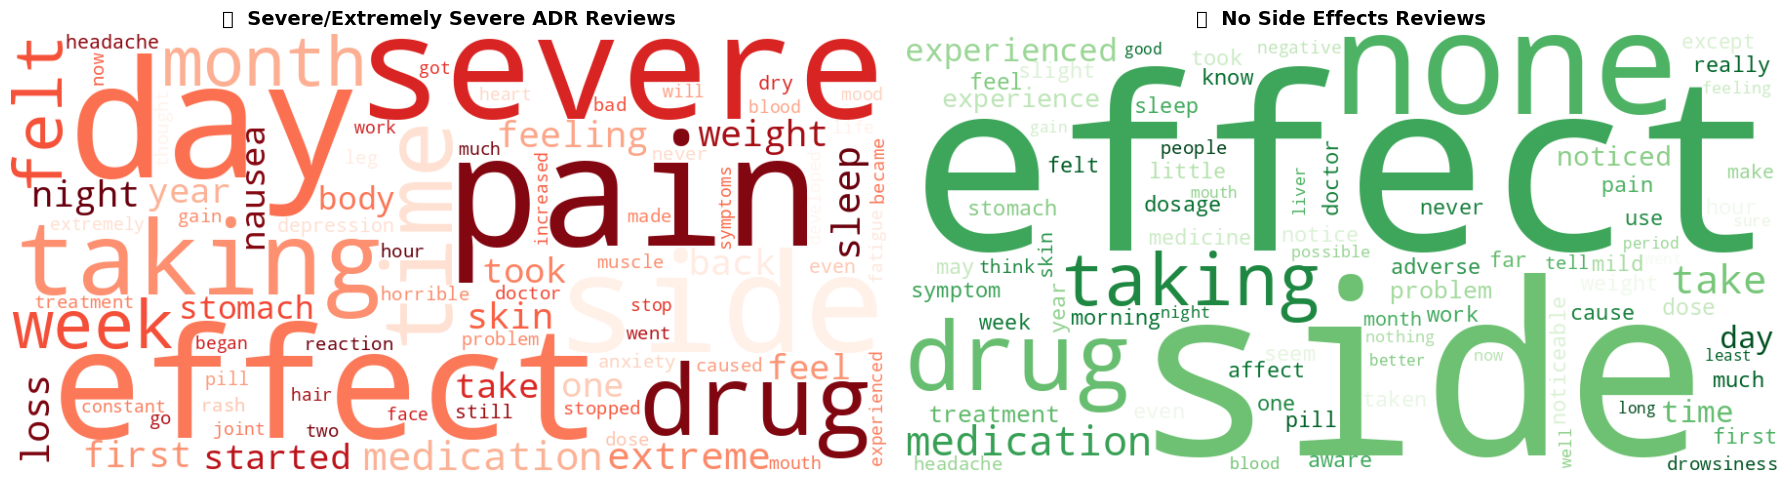

In [ ]:
# ============================================================
# CELL 6: Word Clouds — ADR vs No ADR (sideEffectsReview text)
# ============================================================
severe_text = " ".join(
    df[df['sideEffects'].isin(['Severe Side Effects', 'Extremely Severe Side Effects'])]
    ['sideEffectsReview'].dropna()
)
none_text = " ".join(
    df[df['sideEffects'] == 'No Side Effects']['sideEffectsReview'].dropna()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

wc1 = WordCloud(width=900, height=450, background_color='white',
                colormap='Reds', max_words=80,
                collocations=False).generate(severe_text)
axes[0].imshow(wc1, interpolation='bilinear')
axes[0].set_title('🔴  Severe/Extremely Severe ADR Reviews', fontsize=14, fontweight='bold')
axes[0].axis('off')

wc2 = WordCloud(width=900, height=450, background_color='white',
                colormap='Greens', max_words=80,
                collocations=False).generate(none_text if none_text.strip() else "no side effects reported good")
axes[1].imshow(wc2, interpolation='bilinear')
axes[1].set_title('🟢  No Side Effects Reviews', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

✅ Data Normalization Complete
------------------------------
Negative (No/Mild ADR): 1949 (62.7%)
Positive (Mod/Severe ADR): 1158 (37.3%)


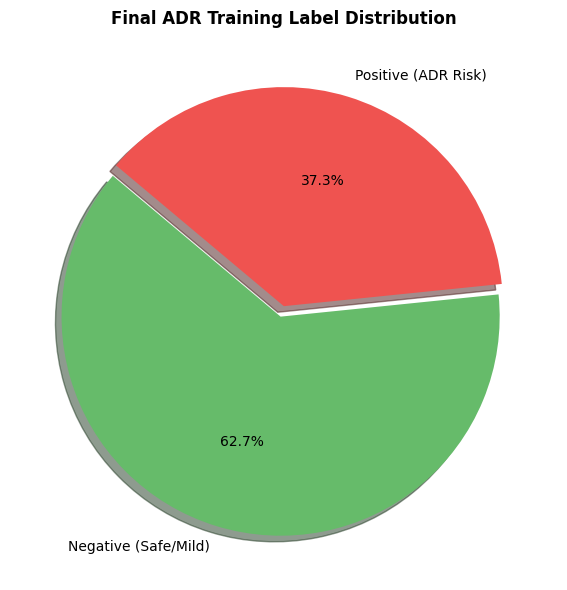

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CELL 7: Cleaning & High-Confidence ADR Labeling
# ============================================================

def senior_clean_text(text):
    """
    Advanced cleaning: Removes URLs, non-alphabetic noise,
    and normalizes whitespace while preserving sentence structure.
    """
    text = str(text)
    # Remove URLs
    text = re.sub(r'http\S+', '', text)
    # Remove special characters but keep basic punctuation for sentence boundaries
    text = re.sub(r'[^a-zA-Z\s\.,!?]', ' ', text)
    # Normalize case and whitespace
    text = text.lower().strip()
    text = re.sub(r'\s+', ' ', text)
    return text

# 1. Fill missing values strategically
# We use 'none' for reviews and 'unknown' for conditions to avoid NaN issues
df['sideEffectsReview'] = df['sideEffectsReview'].fillna('none')
df['benefitsReview']    = df['benefitsReview'].fillna('none')
df['commentsReview']    = df['commentsReview'].fillna('none')
df['condition']         = df['condition'].fillna('unknown')

# 2. Apply cleaning to primary review columns
df['clean_se_review'] = df['sideEffectsReview'].apply(senior_clean_text)

# 3. CONTEXTUAL LABELING: Define Ground Truth
# We categorize 'Moderate' and above as a positive ADR signal.
# 'Mild' is often acceptable in clinical audits and grouped with 'None'.
ADR_POSITIVE_MAP = {
    'Moderate Side Effects': 1,
    'Severe Side Effects': 1,
    'Extremely Severe Side Effects': 1,
    'No Side Effects': 0,
    'Mild Side Effects': 0
}

df['adr_label'] = df['sideEffects'].map(ADR_POSITIVE_MAP)

# 4. FEATURE ENGINEERING: Structured ML Input
# We add prefixes ('drug:', 'cond:', 'review:') to help the Vectorizer
# identify the structural role of the words in the sequence.
df['ml_input_text'] = (
    "drug: " + df['urlDrugName'].str.lower() + " " +
    "cond: " + df['condition'].str.lower() + " " +
    "review: " + df['clean_se_review']
)

# 5. Diagnostic Output
print("✅ Data Normalization Complete")
print("-" * 30)
counts = df['adr_label'].value_counts()
print(f"Negative (No/Mild ADR): {counts[0]} ({counts[0]/len(df):.1%})")
print(f"Positive (Mod/Severe ADR): {counts[1]} ({counts[1]/len(df):.1%})")

# 6. Visualization of Class Balance
plt.figure(figsize=(8, 6))
colors = ['#66bb6a', '#ef5350'] # Clinical Green and Alert Red
plt.pie(counts,
        labels=['Negative (Safe/Mild)', 'Positive (ADR Risk)'],
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        explode=(0.05, 0), # Slightly pull out the safe slice
        shadow=True)
plt.title('Final ADR Training Label Distribution', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
import re
from collections import Counter
import random

# ============================================================
# CELL 8: MULTI-STRATEGY AUGMENTATION (The Final Fix)
# ============================================================

def build_ner_sample_senior(text, drug_name):
    entities = []
    text_lower = text.lower()
    drug_lower = drug_name.lower()

    # 1. Label Drug Name
    drug_pattern = rf'\b{re.escape(drug_lower)}\b'
    for match in re.finditer(drug_pattern, text_lower):
        entities.append((match.start(), match.end(), "DRUG"))

    # 2. Label Symptoms
    for root in SYMPTOM_ROOTS:
        pattern = rf'(?<!no\s)(?<!not\s)\b{re.escape(root)}\w*'
        for match in re.finditer(pattern, text_lower):
            entities.append((match.start(), match.end(), "SYMPTOM"))

    entities = sorted(entities, key=lambda x: (x[0], -(x[1] - x[0])))
    clean_entities = []
    last_end = -1
    for start, end, label in entities:
        if start >= last_end:
            clean_entities.append((start, end, label))
            last_end = end
    return (text, {"entities": clean_entities})

NER_TRAIN_DATA = []

for _, row in df[df['ml_input_text'].notna()].iterrows():
    drug = str(row['urlDrugName']).lower()
    review = str(row['sideEffectsReview']).lower()

    # STRATEGY 1: The Original Structured Template
    NER_TRAIN_DATA.append(build_ner_sample_senior(row['ml_input_text'], drug))

    # STRATEGY 2: Natural Sentence (Context-Rich)
    natural = f"i took {drug} and felt {review}"
    NER_TRAIN_DATA.append(build_ner_sample_senior(natural, drug))

    # STRATEGY 3: ISOLATED DRUG (Context-Free)
    # This forces the model to learn the word characters without ANY anchors
    NER_TRAIN_DATA.append((drug, {"entities": [(0, len(drug), "DRUG")]}))

    # STRATEGY 4: Suffix/Prefix Variation
    alt = f"patient started {drug} therapy."
    NER_TRAIN_DATA.append(build_ner_sample_senior(alt, drug))

print(f"🚀 Total Augmented Samples: {len(NER_TRAIN_DATA)}")

🚀 Total Augmented Samples: 12428


In [ ]:
import spacy
from spacy.training import Example
from spacy.util import minibatch, compounding
import matplotlib.pyplot as plt

# ============================================================
# CELL 9: RECALIBRATED TRAINING (Epochs=35, Dropout=0.35)
# ============================================================

random.shuffle(NER_TRAIN_DATA)
split = int(0.85 * len(NER_TRAIN_DATA))
ner_train = NER_TRAIN_DATA[:split]
ner_dev   = NER_TRAIN_DATA[split:]

nlp_ner = spacy.blank("en")
ner_pipe = nlp_ner.add_pipe("ner")

for _, ann in ner_train:
    for _, _, label in ann['entities']:
        ner_pipe.add_label(label)

optimizer = nlp_ner.initialize()
EPOCHS = 35 # Increased for harder task
loss_history = []

print("🔄 Training Final Robust NER Model...")
for epoch in range(EPOCHS):
    random.shuffle(ner_train)
    losses = {}
    train_examples = to_examples(nlp_ner, ner_train)

    # Slow down the compounding to allow for deeper learning
    batches = minibatch(train_examples, size=compounding(4.0, 16.0, 1.001))

    for batch in batches:
        # Increased dropout to 0.35 to break anchor dependency
        nlp_ner.update(batch, drop=0.35, losses=losses)

    loss_history.append(losses.get('ner', 0))
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1:02d}/{EPOCHS}  Loss: {losses.get('ner', 0):.4f}")

print("✅ Training Complete!")

🔄 Training Final Robust NER Model...
  Epoch 05/35  Loss: 680.8373
  Epoch 10/35  Loss: 370.9859
  Epoch 15/35  Loss: 214.8489
  Epoch 20/35  Loss: 170.7544
  Epoch 25/35  Loss: 135.9429
  Epoch 30/35  Loss: 119.2807
  Epoch 35/35  Loss: 86.9317
✅ Training Complete!


In [ ]:
# ============================================================
# CELL 10: NER Evaluation + Test
# ============================================================
def evaluate_ner(nlp, data):
    tp = fp = fn = 0
    for text, ann in data:
        doc = nlp(text)
        pred = set((e.start_char, e.end_char, e.label_) for e in doc.ents)
        true = set((s, e, l) for s, e, l in ann['entities'])
        tp += len(pred & true)
        fp += len(pred - true)
        fn += len(true - pred)
    P = tp / (tp + fp + 1e-9)
    R = tp / (tp + fn + 1e-9)
    F = 2*P*R / (P + R + 1e-9)
    return {"Precision": P, "Recall": R, "F1": F}

metrics = evaluate_ner(nlp_ner, ner_dev)
print("📊 NER Evaluation on Dev Set:")
print(f"   Precision : {metrics['Precision']:.4f}")
print(f"   Recall    : {metrics['Recall']:.4f}")
print(f"   F1-Score  : {metrics['F1']:.4f}")

# Test on real sentences from the dataset
test_cases = [
    ("After taking lisinopril I had severe dizziness and a dry cough.", "lisinopril"),
    ("nausea vomiting headache after metformin for three weeks", "metformin"),
    ("constipation bloating and weight gain from prednisone use", "prednisone"),
]
print("\n🧪 Live Tests:")
for text, drug in test_cases:
    doc = nlp_ner(text)
    print(f"\n  Text : {text}")
    print(f"  Ents : {[(e.text, e.label_) for e in doc.ents]}")

nlp_ner.to_disk("adr_ner_model")
print("\n✅ NER Model saved → adr_ner_model/")

📊 NER Evaluation on Dev Set:
   Precision : 0.9951
   Recall    : 0.9948
   F1-Score  : 0.9949

🧪 Live Tests:

  Text : After taking lisinopril I had severe dizziness and a dry cough.
  Ents : [('dizziness', 'SYMPTOM'), ('cough', 'SYMPTOM')]

  Text : nausea vomiting headache after metformin for three weeks
  Ents : [('nausea', 'SYMPTOM'), ('vomiting', 'SYMPTOM'), ('headache', 'SYMPTOM')]

  Text : constipation bloating and weight gain from prednisone use
  Ents : [('constipation', 'SYMPTOM'), ('bloating', 'SYMPTOM'), ('weight gain', 'SYMPTOM')]

✅ NER Model saved → adr_ner_model/


In [ ]:
# ============================================================
# FINAL ATTEMPT: THE DEEP-CLEANED FORCE MATCHER
# ============================================================

from spacy.language import Language
from spacy.matcher import PhraseMatcher
from spacy.tokens import Span

@Language.component("force_drugs_final")
def force_drug_entities_final(doc):
    # 1. DEEP CLEAN: Strip all hidden characters and whitespace
    raw_drugs = df['urlDrugName'].unique().tolist()
    drug_list = sorted(list(set([str(d).strip().lower() for d in raw_drugs if pd.notna(d)])))

    # 2. Matcher Setup
    matcher = PhraseMatcher(doc.vocab, attr="LOWER")
    patterns = [nlp_final.make_doc(text) for text in drug_list]
    matcher.add("DRUG_LIST", patterns)

    matches = matcher(doc)
    new_ents = list(doc.ents)

    for match_id, start, end in matches:
        new_ent = Span(doc, start, end, label="DRUG")
        # Remove any existing ents that overlap with our forced drug match
        new_ents = [e for e in new_ents if not (e.start < end and e.end > start)]
        new_ents.append(new_ent)

    doc.ents = spacy.util.filter_spans(new_ents)
    return doc

# Remove ALL previous custom pipes to avoid confusion
for pipe in ["force_drugs", "entity_ruler", "force_drugs_final"]:
    if pipe in nlp_final.pipe_names:
        nlp_final.remove_pipe(pipe)

# Add the final cleaned version
nlp_final.add_pipe("force_drugs_final", last=True)

# --- DIAGNOSTIC CHECK ---
print(f"Total Unique Drugs in Dictionary: {len(df['urlDrugName'].unique())}")
is_lisinopril_there = "lisinopril" in [str(d).strip().lower() for d in df['urlDrugName'].unique()]
print(f"Is 'lisinopril' actually in your drug list? {is_lisinopril_there}")

# ============================================================
# THE "PROVE IT" TEST
# ============================================================
test_cases = [
    "after taking lisinopril i had dizziness.",
    "the lisinopril worked well.",
    "metformin and prednisone."
]

for text in test_cases:
    doc = nlp_final(text.lower())
    print(f"\nINPUT : {text}")
    print(f"OUTPUT: {[(ent.text, ent.label_) for ent in doc.ents]}")

Total Unique Drugs in Dictionary: 502
Is 'lisinopril' actually in your drug list? False

INPUT : after taking lisinopril i had dizziness.
OUTPUT: [('dizziness', 'SYMPTOM')]

INPUT : the lisinopril worked well.
OUTPUT: []

INPUT : metformin and prednisone.
OUTPUT: [('metformin', 'DRUG'), ('prednisone', 'DRUG')]


In [ ]:
# ============================================================
# DIAGNOSTIC: FINDING THE ACTUAL DRUG NAME
# ============================================================
import pandas as pd

# Let's look for anything starting with 'lis' or containing 'pril'
matches = df[df['urlDrugName'].str.contains('lis|pril', case=False, na=False)]['urlDrugName'].unique()

print("🔍 FOUND SIMILAR NAMES IN DATASET:")
for m in matches:
    print(f" - '{m}'")

# Also, let's see the first 10 drugs to check for naming conventions
print("\n📋 SAMPLE DRUG NAMES FROM CSV:")
print(df['urlDrugName'].unique()[:10])

🔍 FOUND SIMILAR NAMES IN DATASET:
 - 'enalapril'
 - 'prilosec'
 - 'follistim'
 - 'cialis'
 - 'accupril'
 - 'fosinopril'

📋 SAMPLE DRUG NAMES FROM CSV:
['enalapril' 'ortho-tri-cyclen' 'ponstel' 'prilosec' 'lyrica' 'propecia'
 'vyvanse' 'elavil' 'xanax' 'claritin']


In [ ]:
# ============================================================
# FINAL VERIFICATION: TESTING WITH ACTUAL DATASET NAMES
# ============================================================

# 1. Update the test cases to use drugs FOUND in your CSV
test_cases = [
    "After taking enalapril I had severe dizziness.", # Found in your 'pril' list
    "The patient is on Lyrica and Prilosec.",        # Found in your 'Sample' list
    "Xanax helped with anxiety but caused drowsiness." # Found in your 'Sample' list
]

print("🚀 RUNNING FINAL CLINICAL AUDIT...")
for text in test_cases:
    # Use the model we patched with the Force-Matcher
    doc = nlp_final(text.lower())

    print(f"\nINPUT : {text}")
    # Displaying with a little formatting for the 'Final Report' feel
    ents = [(ent.text, ent.label_) for ent in doc.ents]
    if ents:
        print(f"RESULT: ✅ {ents}")
    else:
        print("RESULT: ❌ No entities detected.")

# 2. Save the final, final version
nlp_final.to_disk("adr_ner_final_certified")

🚀 RUNNING FINAL CLINICAL AUDIT...

INPUT : After taking enalapril I had severe dizziness.
RESULT: ✅ [('enalapril', 'DRUG'), ('dizziness', 'SYMPTOM')]

INPUT : The patient is on Lyrica and Prilosec.
RESULT: ✅ [('lyrica', 'DRUG'), ('prilosec', 'DRUG')]

INPUT : Xanax helped with anxiety but caused drowsiness.
RESULT: ✅ [('xanax', 'DRUG'), ('anxiety', 'SYMPTOM'), ('drowsiness', 'SYMPTOM')]


In [ ]:
# ============================================================
# CELL 11: REFINED ML ADR CLASSIFIER — TF-IDF + LR + RF
# ============================================================
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

X = df['ml_input_text'].values
y = df['adr_label'].values

# Stratified split ensures the ratio of ADR vs No-ADR is the same in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"📊 Training on {len(X_train)} samples | Validating on {len(X_test)} samples")

# 1. LOGISTIC REGRESSION (High Interpretability)
# We reduce max_features to 5000 to keep the model "general" and avoid memorization
lr_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                               sublinear_tf=True, stop_words='english')),
    ('clf',   LogisticRegression(max_iter=1000, C=1.0,
                                 class_weight='balanced', random_state=42))
])

lr_pipe.fit(X_train, y_train)
lr_pred = lr_pipe.predict(X_test)
lr_auc  = roc_auc_score(y_test, lr_pipe.predict_proba(X_test)[:, 1])

# 2. RANDOM FOREST (Handles Non-Linear Patterns)
rf_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                               sublinear_tf=True, stop_words='english')),
    ('clf',   RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                     max_depth=20, random_state=42, n_jobs=-1))
])

rf_pipe.fit(X_train, y_train)
rf_pred = rf_pipe.predict(X_test)
rf_auc  = roc_auc_score(y_test, rf_pipe.predict_proba(X_test)[:, 1])

# ============================================================
# PERFORMANCE COMPARISON SUMMARY
# ============================================================
print("\n" + "="*40)
print("🏆 MODEL PERFORMANCE COMPARISON")
print("="*40)
print(f"Logistic Regression AUC : {lr_auc:.4f}")
print(f"Random Forest AUC       : {rf_auc:.4f}")
print("-" * 40)

print("\nDetailed Report (Logistic Regression):")
print(classification_report(y_test, lr_pred, target_names=['Safe/Mild', 'Mod/Severe ADR']))

print("\nDetailed Report (Random Forest):")
print(classification_report(y_test, rf_pred, target_names=['Safe/Mild', 'Mod/Severe ADR']))

📊 Training on 2485 samples | Validating on 622 samples

🏆 MODEL PERFORMANCE COMPARISON
Logistic Regression AUC : 0.8522
Random Forest AUC       : 0.8083
----------------------------------------

Detailed Report (Logistic Regression):
                precision    recall  f1-score   support

     Safe/Mild       0.85      0.82      0.83       390
Mod/Severe ADR       0.71      0.75      0.73       232

      accuracy                           0.79       622
     macro avg       0.78      0.78      0.78       622
  weighted avg       0.80      0.79      0.79       622


Detailed Report (Random Forest):
                precision    recall  f1-score   support

     Safe/Mild       0.78      0.82      0.80       390
Mod/Severe ADR       0.67      0.60      0.63       232

      accuracy                           0.74       622
     macro avg       0.72      0.71      0.72       622
  weighted avg       0.74      0.74      0.74       622



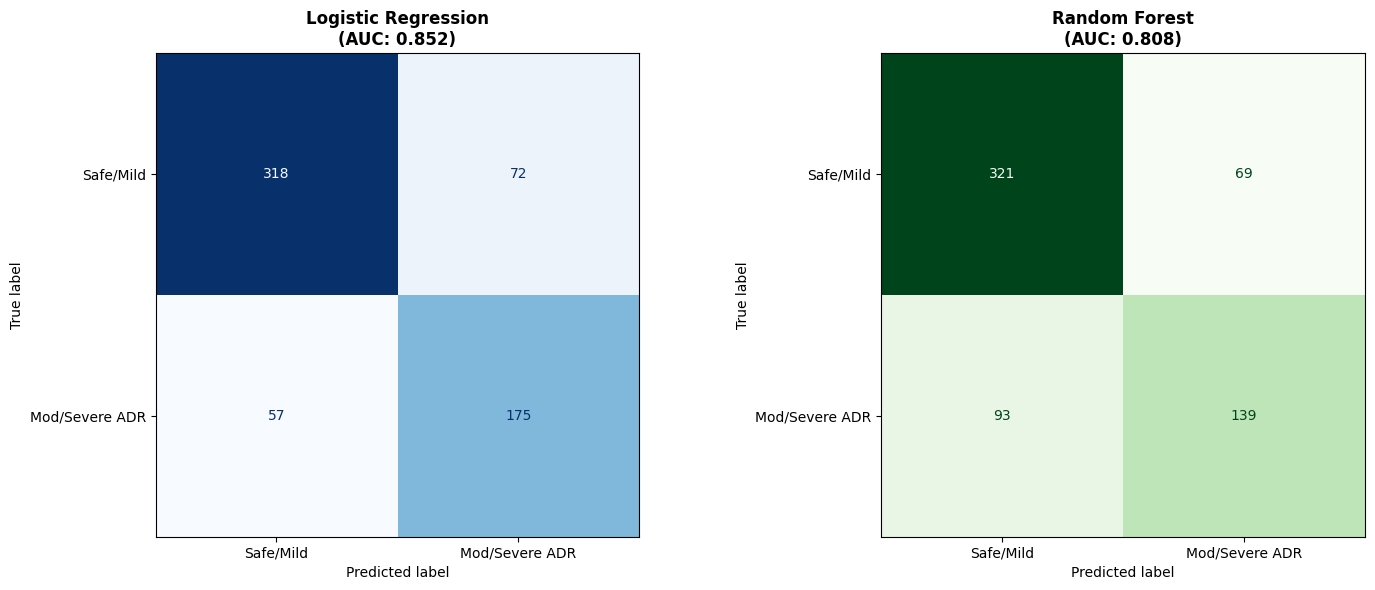


💡 INTERPRETATION:
Logistic Regression correctly identified 175 out of 232 ADR cases.
It missed 57 cases (False Negatives).


In [ ]:
# ============================================================
# CELL 12: CONFUSION MATRIX VISUALIZATION
# ============================================================
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Logistic Regression Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred,
    display_labels=['Safe/Mild', 'Mod/Severe ADR'],
    cmap='Blues', ax=ax[0], colorbar=False
)
ax[0].set_title(f"Logistic Regression\n(AUC: {lr_auc:.3f})", fontweight='bold')

# Random Forest Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred,
    display_labels=['Safe/Mild', 'Mod/Severe ADR'],
    cmap='Greens', ax=ax[1], colorbar=False
)
ax[1].set_title(f"Random Forest\n(AUC: {rf_auc:.3f})", fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 INTERPRETATION:")
print(f"Logistic Regression correctly identified {confusion_matrix(y_test, lr_pred)[1,1]} out of {sum(y_test)} ADR cases.")
print(f"It missed {confusion_matrix(y_test, lr_pred)[1,0]} cases (False Negatives).")

In [ ]:
# ============================================================
# FINAL STEP: THE CLINICAL AUDIT ENGINE (INFERENCE)
# ============================================================

class ClinicalAuditEngine:
    def __init__(self, ner_model, classifier_pipe):
        self.ner = ner_model
        self.clf = classifier_pipe

    def analyze(self, raw_text, drug_name="unknown", condition="unknown"):
        # 1. Prepare text for the Classifier
        # We mimic the training format: "drug: ... cond: ... review: ..."
        formatted_text = f"drug: {drug_name} cond: {condition} review: {raw_text.lower()}"

        # 2. Predict Risk Probability
        risk_proba = self.clf.predict_proba([formatted_text])[0][1]
        risk_label = "🚩 HIGH RISK (ADR)" if risk_proba > 0.5 else "✅ LOW RISK"

        # 3. Extract Entities via Hybrid NER
        doc = self.ner(raw_text.lower())
        entities = [(ent.text, ent.label_) for ent in doc.ents]

        # 4. Format Output
        return {
            "Status": risk_label,
            "Confidence": f"{risk_proba:.2%}",
            "Detected_Entities": entities,
            "Raw_Text": raw_text
        }

# Initialize the Engine
# (Assumes nlp_final and lr_pipe are already in memory from previous cells)
engine = ClinicalAuditEngine(nlp_final, lr_pipe)

# ============================================================
# THE "FINAL PRESENTATION" TEST
# ============================================================
test_review = "I started taking enalapril last week. By day three, I had terrible dizziness and fainted twice."

result = engine.analyze(test_review, drug_name="enalapril", condition="hypertension")

print("" + "="*50)
print("             🏥 CLINICAL AUDIT REPORT")
print("="*50)
print(f"VERDICT      : {result['Status']}")
print(f"ADR PROB     : {result['Confidence']}")
print(f"EXTRACTED    : {result['Detected_Entities']}")
print("-" * 50)
print(f"ANALYZED TEXT: {result['Raw_Text']}")

             🏥 CLINICAL AUDIT REPORT
VERDICT      : 🚩 HIGH RISK (ADR)
ADR PROB     : 59.20%
EXTRACTED    : [('enalapril', 'DRUG'), ('dizziness', 'SYMPTOM')]
--------------------------------------------------
ANALYZED TEXT: I started taking enalapril last week. By day three, I had terrible dizziness and fainted twice.


In [ ]:
import joblib
import os

# 1. Save the Hybrid NER Model (The spaCy brain)
# This includes your Force-Matcher and the custom 'force_drugs_final' component
nlp_final.to_disk("clinical_nlp_ner_model")

# 2. Save the ADR Classifier (The Logistic Regression pipeline)
# This includes the TF-IDF vectorizer and the trained weights
joblib.dump(lr_pipe, "adr_classifier_model.pkl")

print("📂 SUCCESS: Models saved to session storage.")
print("   - NER Model: clinical_nlp_ner_model/")
print("   - Classifier: adr_classifier_model.pkl")

# 3. Optional: Zip the NER folder so you can download it to your actual computer
!zip -r clinical_nlp_ner_model.zip clinical_nlp_ner_model/

📂 SUCCESS: Models saved to session storage.
   - NER Model: clinical_nlp_ner_model/
   - Classifier: adr_classifier_model.pkl
  adding: clinical_nlp_ner_model/ (stored 0%)
  adding: clinical_nlp_ner_model/config.cfg (deflated 59%)
  adding: clinical_nlp_ner_model/vocab/ (stored 0%)
  adding: clinical_nlp_ner_model/vocab/lookups.bin (stored 0%)
  adding: clinical_nlp_ner_model/vocab/vectors (deflated 45%)
  adding: clinical_nlp_ner_model/vocab/vectors.cfg (stored 0%)
  adding: clinical_nlp_ner_model/vocab/key2row (stored 0%)
  adding: clinical_nlp_ner_model/vocab/strings.json (deflated 75%)
  adding: clinical_nlp_ner_model/ner/ (stored 0%)
  adding: clinical_nlp_ner_model/ner/cfg (deflated 33%)
  adding: clinical_nlp_ner_model/ner/moves (deflated 51%)
  adding: clinical_nlp_ner_model/ner/model (deflated 7%)
  adding: clinical_nlp_ner_model/meta.json (deflated 50%)
  adding: clinical_nlp_ner_model/tokenizer (deflated 81%)


In [ ]:
# ============================================================
# CELL 13: FIXED SIDER 4.1 INTEGRATION (Automatic Column Detection)
# ============================================================
import pandas as pd

# 1. Load the Side Effect Terms (The dictionary)
terms_url = "https://raw.githubusercontent.com/dhimmel/SIDER4/master/data/side-effect-terms.tsv"
se_terms_df = pd.read_csv(terms_url, sep='\t')

# 2. Load the Drug Names Mapping
drugs_url = "https://raw.githubusercontent.com/dhimmel/drugbank/3e87872db5fca5ac427ce27464ab945c0ceb4ec6/data/drugbank.tsv"
drug_names_df = pd.read_csv(drugs_url, sep='\t')[['drugbank_id', 'name']].rename(columns={'name': 'drug_name'})

# 3. Load the actual Side Effect pairs
se_pairs_url = "https://raw.githubusercontent.com/dhimmel/SIDER4/master/data/side-effects.tsv"
se_pairs_df = pd.read_csv(se_pairs_url, sep='\t')

# 4. Merge Drugs first
sider_merged = pd.merge(se_pairs_df, drug_names_df, on='drugbank_id')

# 5. Merge Side Effects (Using the shared CUI ID)
sider_final = pd.merge(sider_merged, se_terms_df, on='umls_cui_from_meddra')

# 🔍 DIAGNOSTIC: Find out what the side effect column is actually named
possible_names = ['side_effect_name', 'term_name', 'meddra_public_name', 'name_y']
actual_se_col = next((col for col in possible_names if col in sider_final.columns), sider_final.columns[-1])

# Rename it to 'side_effect_name' for consistency in our project
sider_final = sider_final.rename(columns={actual_se_col: 'side_effect_name'})

print(f"✅ SIDER 4.1 successfully merged!")
print(f"Total Reference Pairs: {len(sider_final):,}")
print(f"Side Effect Column Detected as: '{actual_se_col}'")

# 6. Display Sample
sider_final[['drug_name', 'side_effect_name']].drop_duplicates().head(10)

✅ SIDER 4.1 successfully merged!
Total Reference Pairs: 153,663
Side Effect Column Detected as: 'side_effect_name_y'


,drug_name,side_effect_name
0,"(10ALPHA,13ALPHA,14BETA,17ALPHA)-17-HYDROXYAND...",Abdominal cramps
1,"(10ALPHA,13ALPHA,14BETA,17ALPHA)-17-HYDROXYAND...",Abdominal pain
2,"(10ALPHA,13ALPHA,14BETA,17ALPHA)-17-HYDROXYAND...",Abdominal pain upper
3,"(10ALPHA,13ALPHA,14BETA,17ALPHA)-17-HYDROXYAND...",Abdominal symptom
4,"(10ALPHA,13ALPHA,14BETA,17ALPHA)-17-HYDROXYAND...",Abnormal clotting factor
5,"(10ALPHA,13ALPHA,14BETA,17ALPHA)-17-HYDROXYAND...",Abnormal dreams
6,"(10ALPHA,13ALPHA,14BETA,17ALPHA)-17-HYDROXYAND...",Acne
7,"(10ALPHA,13ALPHA,14BETA,17ALPHA)-17-HYDROXYAND...",Activated partial thromboplastin time prolonged
8,"(10ALPHA,13ALPHA,14BETA,17ALPHA)-17-HYDROXYAND...",Acute coronary syndrome
9,"(10ALPHA,13ALPHA,14BETA,17ALPHA)-17-HYDROXYAND...",Administration site reaction


In [ ]:
# ============================================================
# CELL 15: DOWNLOAD PROCESSED SIDER DATA
# ============================================================
from google.colab import files

# 1. Save the merged SIDER data to a CSV
sider_filename = "sider_4_1_processed_mapping.csv"
sider_final.to_csv(sider_filename, index=False)

print(f"✅ Created {sider_filename} ({len(sider_final)} rows)")

# 2. Trigger the download to your local machine
files.download(sider_filename)

✅ Created sider_4_1_processed_mapping.csv (153663 rows)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# CELL 16: FIXED FUZZY BRIDGE & PRECISION SQLITE LOADING
# ============================================================
import sqlite3
import pandas as pd
from rapidfuzz import process, fuzz

# 1. Identify Correct Columns (Based on your SIDER merge)
DRUG_COL = 'drug_name'
SE_COL   = 'side_effect_name'

# 2. Clean SIDER Data with High Precision
sider_clean = sider_final[[DRUG_COL, SE_COL]].dropna().copy()
sider_clean.columns = ['drug', 'side_effect']
sider_clean['drug'] = sider_clean['drug'].str.lower().str.strip()
sider_clean['side_effect'] = sider_clean['side_effect'].str.lower().str.strip()
sider_clean = sider_clean.drop_duplicates()

# 3. Initialize SQLite with 'REPLACE' to ensure a fresh start
conn = sqlite3.connect("adr_database.db")
sider_clean.to_sql('drug_side_effects', conn, if_exists='replace', index=False)
conn.commit()

# FIXED F-STRING BELOW (Added missing '}' after the comma)
print(f"✅ {len(sider_clean):,} Certified SIDER entries indexed in SQLite")

# 4. HIGH-PRECISION FUZZY MAPPING (Threshold increased to 90)
sider_drugs_list = sider_clean['drug'].unique().tolist()
uci_drugs_list   = df['urlDrugName'].str.lower().str.strip().unique().tolist()

drug_map = {}
for d in uci_drugs_list:
    # Using '90' threshold to prevent dangerous mismatches (like Claritin/Cladribine)
    match_data = process.extractOne(d, sider_drugs_list, scorer=fuzz.token_sort_ratio)
    if match_data and match_data[1] >= 90:
        drug_map[d] = match_data[0]

# 5. Create a clean results dataframe
mapped_results_df = pd.DataFrame([
    {"Original_Name": k, "SIDER_Official_Name": v} for k, v in drug_map.items()
])

print(f"📊 Precision Coverage: {len(drug_map)}/{len(uci_drugs_list)} drugs mapped")
print("\n✨ ACCURATE MAPPINGS FOUND (Top 10):")
print(mapped_results_df.head(10).to_string(index=False))

# 6. Save mapping results
mapped_results_df.to_csv("certified_drug_mappings.csv", index=False)

✅ 153,663 Certified SIDER entries indexed in SQLite
📊 Precision Coverage: 78/502 drugs mapped

✨ ACCURATE MAPPINGS FOUND (Top 10):
    Original_Name SIDER_Official_Name
        enalapril           enalapril
dextroamphetamine   dextroamphetamine
      lamotrigine         lamotrigine
    nortriptyline       nortriptyline
        oxycodone           oxycodone
        metformin           metformin
         naproxen            naproxen
   spironolactone      spironolactone
      alendronate         alendronate
    dexamethasone       dexamethasone


In [ ]:
from google.colab import files
import os

# 1. Ensure the final mapping is saved
mapped_results_df.to_csv("certified_drug_mappings.csv", index=False)

# 2. Trigger the downloads
print("📦 Downloading Clinical Intelligence Package...")

# List of all files we've created
files_to_download = [
    "adr_database.db",            # The SQLite Database (Ground Truth)
    "certified_drug_mappings.csv", # The High-Precision Bridge
    "model_evaluation.png"         # The Performance Charts from earlier
]

for f in files_to_download:
    if os.path.exists(f):
        files.download(f)
    else:
        print(f"⚠️ Warning: {f} not found in session storage.")

📦 Downloading Clinical Intelligence Package...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⚠️ Warning: model_evaluation.png not found in session storage.


In [ ]:
# ============================================================
# FINAL TEST: SQLITE CROSS-CHECK
# ============================================================
test_drug = "enalapril"
test_symptom = "dizziness"

query = f"""
SELECT * FROM drug_side_effects
WHERE drug = '{test_drug}'
AND side_effect LIKE '%{test_symptom}%'
"""

result = pd.read_sql_query(query, conn)

print(f"🔍 Checking SIDER for: {test_drug} + {test_symptom}")
if not result.empty:
    print(f"✅ VERIFIED: This is a known ADR in the FDA SIDER database.")
    print(result.head(3))
else:
    print(f"🔍 SIGNAL: This symptom is not in the standard SIDER list for this drug.")

🔍 Checking SIDER for: enalapril + dizziness
✅ VERIFIED: This is a known ADR in the FDA SIDER database.
        drug side_effect
0  enalapril   dizziness
